# Introduzione

Questo progetto simula una situazione reale in cui occorre integrare fonti dati multiple, ottimizzare memoria, applicare filtri complessi, aggregazioni avanzate e serializzazione efficiente. Il progetto è suddiviso nelle seguenti 4 parti:

1. **Generazione Dataset**: 
    - ordini.csv;
    - prodotti.json;
    - clienti.csv.

2. **Creare DataFrame unificato**:
    - unire ordini.csv, prodotti.json e clienti.csv in un unico DataFrame. 

3. **Ottimizzazione risorse e performance**:
    - ottimizzare i tipi di dato;
    - ottimizzare l'uso della memoria.

4. **Analisi Dati**: 
    - esplorazione daraset;
    - analisi incasso;
    - analisi categoriche;
    - grafici riassuntivi.

## Import Librerie

In [24]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from pathlib import Path
from scipy import stats


# Generazione Dataset
In questa sezione verranno generati randomicamente i seguenti Dataset:

1. **ordini.csv**, **100.000 righe** con le seguenti features:
    - **ClienteID**, tipo **stringa** nel formato **id-XXXX**;
    - **ProdottoID**, tipo **stringa** nel formato **prod-XXX**;
    - **Quantità**, tipo **intero**;
    - **DataOrdine**, tipo **stringa** nel formato **gg/mm/aaaa**.

2. **prodotti.json**, **20 prodotti** con le seguenti features;
    - **ID**, tipo **stringa** nel formato **prod-XXX**;
    - **Prezzo**, tipo **float**;
    - **Categoria**, tipo **stringa**;
    - **Fornitore**, tipo **stringa**.

3. **clienti.csv**, **5.000 righe** con le seguenti features:
    - **ID**, tipo **stringa** nel formato **id-XXXX**;
    - **Regione**, tipo **stringa**,
    - **Segmento**, tipo **stringa**.

## Funzioni Ausiliarie
Nella seguente cella di codice sono implementate due funzione per generare i codici ID:

- **prod_id()** genera codici ID per i Prodotti;
- **cli_id()** genera codici ID per i Clienti;
- **bar_value()** aggiunge informazioni sui grafici a barre.

In [ ]:
## FUNZIONI AUSILIARIE 

# Codice Prodotto
def prod_id(n):
    """
    Genera un codice identificativo univoco per un prodotto.
    
    Parameters
    ----------
    n : int
        Numero progressivo del prodotto.
    
    Returns
    -------
    str
        Codice ID nel formato 'prod-XXX' dove XXX è un numero a 3 cifre
        con zeri iniziali (es: 'prod-001', 'prod-042', 'prod-123').
    """
    return f"prod-{n:03d}"

# Codice Cliente
def cli_id(n):
    """
    Genera un codice identificativo univoco per un cliente.
    
    Parameters
    ----------
    n : int
        Numero progressivo del cliente.
    
    Returns
    -------
    str
        Codice ID nel formato 'cli-XXXX' dove XXXX è un numero a 4 cifre
        con zeri iniziali (es: 'cli-0001', 'cli-0042', 'cli-1234').
    
    """
    return f"cli-{n:04d}"

# Aggiunge numero su barre nei grafici
def bar_value(ax, bars):
    """
    Aggiunge valore numerico sopra ogni barra corrispondente 
    all'altezza della barra stessa.
    """
    
    for bar in bars:
        height = bar.get_height()               # estraggo altezza barra
        width = bar.get_width()                 # estraggo larghezza barra
        edge = bar.get_x()                      # estraggo posizione bordo barra
        ax.text(
            edge + width/2,                     # x: centro barra
            height,                             # y: altezza barra
            f'{height:,.0f}',                    # testo da aggiungere
            ha='center', va='bottom',           # posizione testo 
            fontsize=8, fontweight='bold'       # parametri font
        )

## Datasets 
Nei seguenti blocchi di codici verranno generati e salvati i vari Dataset.

In [ ]:
## DATASET ORDINI

# Numero righe
n_righe = 100_000

# ID Clienti 
clienti_id = [cli_id(n) for n in np.random.randint(1, 5001, n_righe)]

# ID Prodotti
prodotti_id = [prod_id(n) for n in np.random.randint(1, 21, n_righe)]

# Quantità
shift = 1
quantita = (np.random.poisson(lam = 3, size = n_righe) + shift).astype(int)

# Date, coprono un periodo di 1 anno dal 2025-01-01
start =  datetime(2025, 1, 1)                           # data d'inizio
date = [
    (start + timedelta(days=i)).strftime('%d/%m/%Y')    # converto in stringa nel formato gg/mm/aaaa
    for i in range(365)
]

# Data Ordine, scelte randomicamente dalla lista date
date_ordini = np.random.choice(date, n_righe)

# Creo Dataset 
dataset_ordini = {
    'Data_Ordine': date_ordini,
    'Cliente_ID': clienti_id,
    'Prodotto_ID': prodotti_id,
    'Quantita': quantita
}

# Converto in DataFrame 
df = pd.DataFrame(dataset_ordini)

# Stampo Info e prime righe DataFrame
print(f"{'='*80}")
print("Info DataFrame")
print(f"{'='*80}")
df.info(memory_usage='deep')

print(f"\n{'='*80}")
print("Prime righe DataFrame")
print(f"{'='*80}")
print(df.head().to_string(index=False))

# Salvo DataFrame in CSV
output_ordini = Path('ordini.csv')
df.to_csv(output_ordini, index=False, encoding='utf-8')

print(f"\n{'='*80}")
print(f"Salvataggio DataFrame Ordini nel formato CSV")
print(f"{'='*80}")
print(f"DataFrame salvato con successo!")
print(f"File: {output_ordini.name}")
print(f"Percorso completo: {output_ordini.absolute()}")
print(f"Dimensione: {output_ordini.stat().st_size / 1024:.2f} KB")
print(f"{'='*80}")

Info DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Data_Ordine  100000 non-null  object
 1   Cliente_ID   100000 non-null  object
 2   Prodotto_ID  100000 non-null  object
 3   Quantita     100000 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 17.3 MB

Prime righe DataFrame
Data_Ordine Cliente_ID Prodotto_ID  Quantita
 04/11/2025   cli-3905    prod-007         8
 24/03/2025   cli-0354    prod-015         4
 26/10/2025   cli-2512    prod-001         4
 18/06/2025   cli-4726    prod-012         5
 14/04/2025   cli-3521    prod-008         5

Salvataggio DataFrame Ordini nel formato CSV
DataFrame salvato con successo!
File: ordini.csv
Percorso completo: /media/paolo/DATA/Backup/python_workspace/EPICODE/MODULO_2/ordini.csv
Dimensione: 3027.76 KB


In [27]:
## DATASET PRODOTTI

# ID Prodotti
prodotti_id = [prod_id(i) for i in range(1,21)]

# Prezzo prodotti 
prezzo_prodotti = [
    29.99, 149.90, 12.50, 89.00, 45.00, 
    199.99, 8.90, 34.50, 67.80, 120.00,
    15.99, 78.50, 250.00, 19.90, 99.99,
    42.00, 156.80, 24.99, 310.00, 55.50
]

# Regione Prodotti  
categoria = [
    'Elettronica', 'Elettronica', 'Alimentari', 'Abbigliamento', 'Casa',
    'Elettronica', 'Alimentari', 'Casa', 'Abbigliamento', 'Elettronica',
    'Alimentari', 'Abbigliamento', 'Elettronica', 'Casa', 'Abbigliamento',
    'Casa', 'Elettronica', 'Alimentari', 'Elettronica', 'Abbigliamento'
]

# Fornitore Prodotti
fornitore = [
    'TechSupply', 'TechSupply', 'FoodDistrib', 'FashionHub', 'HomeDecor',
    'ElectroWorld', 'FoodDistrib', 'HomeDecor', 'FashionHub', 'TechSupply',
    'FoodDistrib', 'FashionHub', 'ElectroWorld', 'HomeDecor', 'FashionHub',
    'HomeDecor', 'TechSupply', 'FoodDistrib', 'ElectroWorld', 'FashionHub'
]

# Creo Dataset
dataset_prodotti = {
    'ID': prodotti_id,
    'Prezzo': prezzo_prodotti,
    'Categoria': categoria,
    'Fornitore': fornitore 
}

# Converto in DataFrame
df = pd.DataFrame(dataset_prodotti)

# Stampo Info e prime righe DataFrame
print(f"{'='*80}")
print("Info DataFrame")
print(f"{'='*80}")
df.info(memory_usage='deep')

print(f"\n{'='*80}")
print("Prime righe DataFrame")
print(f"{'='*80}")
print(df.head().to_string(index=False))

# Salvo DataFrame in JSON
output_prodotti = Path('prodotti.json')
df.to_json(
    output_prodotti, 
    orient='records',   # lista di dizionari
    indent=2,           # per leggibilità
    force_ascii=False
)

print(f"\n{'='*80}")
print(f"Salvataggio DataFrame Prodotti nel formato JSON")
print(f"{'='*80}")
print(f"DataFrame salvato con successo!")
print(f"File: {output_prodotti.name}")
print(f"Percorso completo: {output_prodotti.absolute()}")
print(f"Dimensione: {output_prodotti.stat().st_size / 1024:.2f} KB")
print(f"{'='*80}")

Info DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         20 non-null     object 
 1   Prezzo     20 non-null     float64
 2   Categoria  20 non-null     object 
 3   Fornitore  20 non-null     object 
dtypes: float64(1), object(3)
memory usage: 3.7 KB

Prime righe DataFrame
      ID  Prezzo     Categoria   Fornitore
prod-001   29.99   Elettronica  TechSupply
prod-002  149.90   Elettronica  TechSupply
prod-003   12.50    Alimentari FoodDistrib
prod-004   89.00 Abbigliamento  FashionHub
prod-005   45.00          Casa   HomeDecor

Salvataggio DataFrame Prodotti nel formato JSON
DataFrame salvato con successo!
File: prodotti.json
Percorso completo: /media/paolo/DATA/Backup/python_workspace/EPICODE/MODULO_2/prodotti.json
Dimensione: 2.12 KB


In [28]:
## DATASET CLIENTI

# ID Clienti
clienti_id = [cli_id(i) for i in range(1, 5001)]

# Regioni 
regioni = ['Nord', 'Centro', 'Sud', 'Isole']

# Sgmenti Clienti 
segmenti = ['Consumer', 'Corporate']

# Creo Dataset
dataset_clienti = {
    'ID': clienti_id,
    'Regione': np.random.choice(regioni, len(clienti_id)),
    'Segmento': np.random.choice(segmenti, len(clienti_id))
}

# Creo DataFrame
df = pd.DataFrame(dataset_clienti)

# Stampo Info e prime righe DataFrame
print(f"{'='*80}")
print("Info DataFrame")
print(f"{'='*80}")
df.info(memory_usage='deep')

print(f"\n{'='*80}")
print("Prime righe DataFrame")
print(f"{'='*80}")
print(df.head().to_string(index=False))

# Salvo DataFrame in CSV
output_clienti = Path('clienti.csv')
df.to_csv(output_clienti, index=False, encoding='utf-8')

print(f"\n{'='*80}")
print(f"Salvataggio DataFrame Clienti nel formato CSV")
print(f"{'='*80}")
print(f"DataFrame salvato con successo!")
print(f"File: {output_clienti.name}")
print(f"Percorso completo: {output_clienti.absolute()}")
print(f"Dimensione: {output_clienti.stat().st_size / 1024:.2f} KB")
print(f"{'='*80}")

Info DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ID        5000 non-null   object
 1   Regione   5000 non-null   object
 2   Segmento  5000 non-null   object
dtypes: object(3)
memory usage: 820.4 KB

Prime righe DataFrame
      ID Regione  Segmento
cli-0001     Sud Corporate
cli-0002     Sud  Consumer
cli-0003    Nord  Consumer
cli-0004     Sud  Consumer
cli-0005     Sud Corporate

Salvataggio DataFrame Clienti nel formato CSV
DataFrame salvato con successo!
File: clienti.csv
Percorso completo: /media/paolo/DATA/Backup/python_workspace/EPICODE/MODULO_2/clienti.csv
Dimensione: 117.16 KB


# DataFrame Unificato
Nella seguente sezione verranno unificati i vari Dataset precedentemente creati in un unico DataFrame coerente, tenendo conto dei diversi nomi dati alle features corrispondenti:

- **ID** in clienti.csv $\rightarrow$ **Cliente_ID** in ordini.csv;
- **ID** in prodotti.json $\rightarrow$ **Prodotto_ID** in ordini.csv.


In [ ]:
## DATAFRAME UNIFICATO

# Carico Dataset ordini.csv
df_ordini = pd.read_csv(
    'ordini.csv', 
    encoding='utf-8',
    parse_dates=['Data_Ordine'],    # converto in datetime nel formato aaaa-mm-gg    
    dayfirst=True                   # specifico il formato di partenza gg/mm/aaaa
)

# Carico Dataset prodotti.json
df_prodotti = pd.read_json(
    'prodotti.json',
    orient='records'    # struttura dei dati (lista di dizionari)    
)

# Carico Dataset clienti.csv
df_clienti = pd.read_csv(
    'clienti.csv', 
    encoding='utf-8', 
)

# Merge ordini-prodotti
df_prodotti = df_prodotti.rename(columns={'ID': 'Prodotto_ID'})   # rinomino colonna 'ID'
df = pd.merge(
    df_ordini,          # left dataframe
    df_prodotti,        # right dataframe
    on='Prodotto_ID'    # colonna per join
)

# Merge (oridini/prodotti)-clienti
df_clienti = df_clienti.rename(columns={'ID': 'Cliente_ID'})   # rinomino colonna 'ID'
df = pd.merge(
    df,                            # left dataframe
    df_clienti,                    # right dataframe
    on='Cliente_ID'                # colonna per join
).sort_values(by='Data_Ordine')    # riordino per data     

# Stampo i DataFrame di partenza e quello unificato
print(f"{'='*80}")
print("Prime righe DataFrame Ordini")
print(f"{'='*80}")
print(df_ordini.head().to_string(index=False))

print(f"\n{'='*80}")
print("Prime righe DataFrame Prodotti")
print(f"{'='*80}")
print(df_prodotti.head().to_string(index=False))

print(f"\n{'='*80}")
print("Prime righe DataFrame Clienti")
print(f"{'='*80}")
print(df_clienti.head().to_string(index=False))

print(f"\n{'='*80}")
print("Prime righe DataFrame Unificato")
print(f"{'='*80}")
print(df.head().to_string(index=False))
print(f"{'='*80}")


Prime righe DataFrame Ordini
Data_Ordine Cliente_ID Prodotto_ID  Quantita
 2025-11-04   cli-3905    prod-007         8
 2025-03-24   cli-0354    prod-015         4
 2025-10-26   cli-2512    prod-001         4
 2025-06-18   cli-4726    prod-012         5
 2025-04-14   cli-3521    prod-008         5

Prime righe DataFrame Prodotti
Prodotto_ID  Prezzo     Categoria   Fornitore
   prod-001   29.99   Elettronica  TechSupply
   prod-002  149.90   Elettronica  TechSupply
   prod-003   12.50    Alimentari FoodDistrib
   prod-004   89.00 Abbigliamento  FashionHub
   prod-005   45.00          Casa   HomeDecor

Prime righe DataFrame Clienti
Cliente_ID Regione  Segmento
  cli-0001     Sud Corporate
  cli-0002     Sud  Consumer
  cli-0003    Nord  Consumer
  cli-0004     Sud  Consumer
  cli-0005     Sud Corporate

Prime righe DataFrame Unificato
Data_Ordine Cliente_ID Prodotto_ID  Quantita  Prezzo   Categoria    Fornitore Regione  Segmento
 2025-01-01   cli-4474    prod-003         3   12.50  Alim

# Ottimizzazione Risorse e Performance

In questa sezione verrà effettuato un Downcasting di tutte le features del DataFrame unificato riducendo l'uso della della memoria:

- features testuali: **stringa** $\rightarrow$ **category**;
- feature Prezzo: **float64** $\rightarrow$ **float32**;
- feature Quantita: **int64** $\rightarrow$ **int32**;
- feature Data_Ordine: già convertito e formattato durante il caricamento di ordini.csv nella sezione precedente.
 
 Il DataFrame verrà poi salvato nel formato Parquet garantendo quindi alte prestazione in lettura/scrittura e una buona compressione per ottimizzare le risorse di archiviazione.

In [30]:
## OTTIMIZZAZIONE RISORSE E PERFORMANCE

# Stampo Info e prime righe del Dataframe prima dell'ottimizzazione
print(f"{'='*80}")
print("Info DataFrame prima del Downcasting")
print(f"{'='*80}")
df.info(memory_usage='deep')

# Effettuo Downcasting 
for col in df.columns:                          # per ogni colonna...          
    col_type = df[col].dtype                    # controllo il tipo di dato

    if col_type == int:                         # se int...
       df[col] = df[col].astype('int32')        # converto in int32

    if col_type == float:                       # se float...
        df[col] = df[col].astype('float32')     # converto in float32
    
    if col_type == object:                      # se object (stringa)...
        df[col] = df[col].astype('category')    # converto in category

# Stampo Info e prime righe del Dataframe dopo l'ottimizzazione
print(f"\n{'='*80}")
print("Info DataFrame dopo il Downcasting")
print(f"{'='*80}")
df.info(memory_usage='deep')

# Salvo DataFrame in Parquet
output_parquet = Path('dati_vendite.parquet')
df.to_parquet('dati_vendite.parquet')

print(f"\n{'='*80}")
print(f"Salvataggio DataFrame Unificato nel formato Parquet")
print(f"{'='*80}")
print(f"DataFrame salvato con successo!")
print(f"File: {output_parquet.name}")
print(f"Percorso completo: {output_parquet.absolute()}")
print(f"Dimensione: {output_parquet.stat().st_size / 1024**2:.2f} MB")
print(f"{'='*80}")

Info DataFrame prima del Downcasting
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 17230 to 38693
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Data_Ordine  100000 non-null  datetime64[ns]
 1   Cliente_ID   100000 non-null  object        
 2   Prodotto_ID  100000 non-null  object        
 3   Quantita     100000 non-null  int64         
 4   Prezzo       100000 non-null  float64       
 5   Categoria    100000 non-null  object        
 6   Fornitore    100000 non-null  object        
 7   Regione      100000 non-null  object        
 8   Segmento     100000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(6)
memory usage: 35.8 MB

Info DataFrame dopo il Downcasting
<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 17230 to 38693
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       ------------

# Analisi Dati 
In questa sezione verrà analizzato il DataFrame di vendite come segue:

- Panoramica dataset;
- Statistiche descrittive delle features numeriche ('Quantita' e 'Prezzo');
- Analisi Incasso;
- Analisi per categoria prodotti;
- Analisi pe Regioni;
- Prodotti più venduti;
- Clienti migliori;
- Grafici riassuntivi.

In [31]:
## ANALISI DATI 

# Carico DataFrame
df = pd.read_parquet('dati_vendite.parquet')

# Panoramica DataFrame
print(f"{'='*80}")
print("Panoramica DataFrame")
print(f"{'='*80}")
print(f"Numero totale di records: {len(df)}")
print(f"Dimensioni: {df.shape[0]} righe - {df.shape[1]} colonne")
print(f"Memoria utilizzata: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Statistiche descrittive features numeriche
print(f"\n{'='*80}")
print("Statistiche Descrittive Features Numeriche")
print(f"{'='*80}")
print(df.describe(include=[int, float]).round(2))

# Calcolo incasso ordini
df['Incasso'] = df['Prezzo'] * df['Quantita']

# Calcolo incasso totale
incasso_totale = df['Incasso'].sum()

# Calcolo incasso medio giornaliero
media_giornaliera = df.groupby('Data_Ordine')['Incasso'].mean().mean()

# Filtro ordini 
ordini_totali = len(df)
ordini_bassi = df.query('Incasso < 50')['Incasso'].count()
ordini_medi = df.query('Incasso >= 50 and Incasso < 500')['Incasso'].count()
ordini_alti = df.query('Incasso >= 500')['Incasso'].count()

print(f"\n{'='*80}")
print("Analisi Incasso")
print(f"{'='*80}")
print(df[['Prezzo','Quantita','Incasso']].head().to_string(index=False, float_format='%.2f'))
print(f"{'-'*80}")
print(f"Incasso Totale: {incasso_totale:.2f}")
print(f"Incasso Medio Giornaliero: {media_giornaliera:.2f}")
print(f"{'-'*80}")
print(f"Numero Totale Ordini: {ordini_totali}")
print(f"Numero Ordini Bassi (< €50): {ordini_bassi} ({100*ordini_bassi/ordini_totali:.2f}%)")
print(f"Numero Ordini Medi (> €50, < €500): {ordini_medi} ({100*ordini_medi/ordini_totali:.2f}%)")
print(f"Numero Ordini Alti (> €500): {ordini_alti} ({100*ordini_alti/ordini_totali:.2f}%)")

# Analisi per Categoria
analisi_categoria = df.groupby('Categoria', observed=True).agg(
    Incasso_Totale = ('Incasso', 'sum'),
    Ordini_Totali = ('Incasso', 'count'),
    Quantita_Totale = ('Quantita', 'sum'),
    Quantita_Media = ('Quantita', 'mean')
)

print(f"\n{'='*80}")
print("Analisi per Categoria")
print(f"{'='*80}")
print(analisi_categoria.to_string(float_format='%.2f'))

# Analisi Regioni
analisi_regioni = df.groupby('Regione', observed=True).agg(
    Incasso_Totale = ('Incasso', 'sum'),
    Ordini_Totali = ('Incasso', 'count'),
    Quantita_Totale = ('Quantita', 'sum'),
    Quantita_Media = ('Quantita', 'mean')    
)

print(f"\n{'='*80}")
print("Analisi per Regione")
print(f"{'='*80}")
print(analisi_regioni.to_string(float_format='%.2f'))

# Top 10 prodotti
top_prodotti = df.groupby('Prodotto_ID', observed=True).agg(
    Quantita_Totale = ('Quantita', 'sum')
).sort_values(by='Quantita_Totale', ascending=False).head(10)

print(f"\n{'='*80}")
print("Top 10 Prodotti più Venduti")
print(f"{'='*80}")
print(top_prodotti.to_string())

# Top 10 clienti
top_clienti = df.groupby('Cliente_ID', observed=True).agg(
    Spesa_Totale = ('Incasso', 'sum')
).sort_values(by='Spesa_Totale', ascending=False).head(10)

print(f"\n{'='*80}")
print("Top 10 Clienti per Spesa Totale")
print(f"{'='*80}")
print(top_clienti.to_string(float_format='%.2f'))
print(f"{'='*80}")


Panoramica DataFrame
Numero totale di records: 100000
Dimensioni: 100000 righe - 9 colonne
Memoria utilizzata: 3.36 MB

Statistiche Descrittive Features Numeriche
        Quantita     Prezzo
count  100000.00  100000.00
mean        4.01      90.72
std         1.73      82.29
min         1.00       8.90
25%         3.00      24.99
50%         4.00      67.80
75%         5.00     149.90
max        14.00     310.00

Analisi Incasso
 Prezzo  Quantita  Incasso
  12.50         3    37.50
  45.00         6   270.00
 149.90         2   299.80
  42.00         5   210.00
 199.99         7  1399.93
--------------------------------------------------------------------------------
Incasso Totale: 36358073.37
Incasso Medio Giornaliero: 363.57
--------------------------------------------------------------------------------
Numero Totale Ordini: 100000
Numero Ordini Bassi (< €50): 11323 (11.32%)
Numero Ordini Medi (> €50, < €500): 65150 (65.15%)
Numero Ordini Alti (> €500): 23527 (23.53%)

Analisi per C

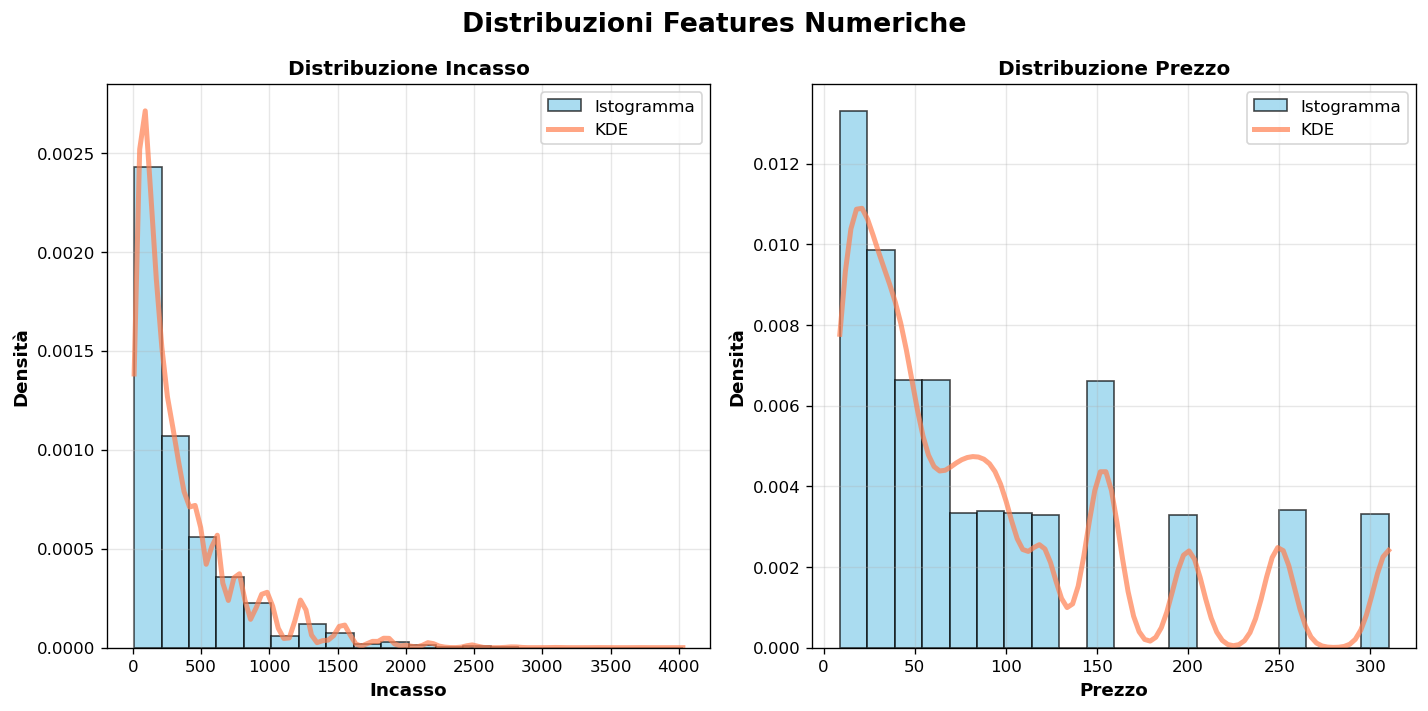

In [32]:
## GRAFICO DISTRIBUZIONI FEATURES NUMERICHE

fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=120)
fig.suptitle(f'Distribuzioni Features Numeriche', fontsize=16, fontweight='bold')

for idx, col in enumerate(['Incasso', 'Prezzo']):
    # Calcolo KDE
    kde = stats.gaussian_kde(df[col])
    x_range = np.linspace(df[col].min(), df[col].max(), 100)
    # Aggiungo istogramma
    axes[idx].hist(
        df[col], bins=20, density=True, 
        alpha=0.7, color='skyblue', edgecolor='black',
        label='Istogramma'
    )
    # Aggiungo KDE
    axes[idx].plot(
        x_range, kde(x_range),
        alpha=0.7, color='coral', linewidth=3,
        label='KDE'
    )
    # Styling   
    axes[idx].set_xlabel(col, fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Densità', fontsize=11, fontweight='bold')
    axes[idx].set_title(f"Distribuzione {col}", fontsize=12, fontweight='bold')
    axes[idx].legend(loc='best')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

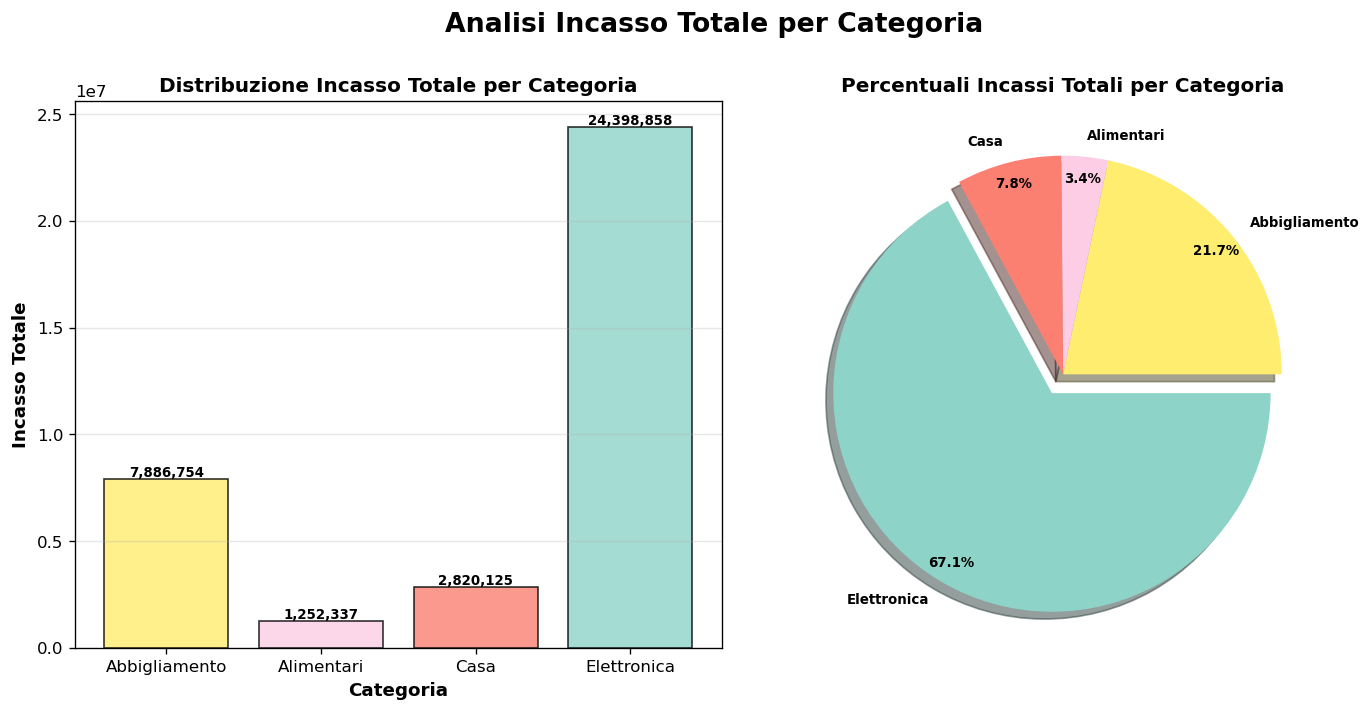

In [ ]:
## GRAFICO DISTRIBUZIONE INCASSO TOTALE PER CATEGORIA

fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=120)
fig.suptitle(f'Analisi Incasso Totale per Categoria', fontsize=16, fontweight='bold')

# Mappa colori per grafico a barre e grafico a torta
colors = plt.cm.Set3_r(np.linspace(0, 1, len(analisi_categoria)))

# >>> Subplot 1 - Grafico a barre <<<

# Aggiungo barre
bars = axes[0].bar(analisi_categoria.index, analisi_categoria['Incasso_Totale'],
    color=colors, edgecolor='black', alpha=0.8)

# Aggiungo valore numerico sopra ogni barra
bar_value(axes[0], bars)

# Styling
axes[0].set_xlabel('Categoria', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Incasso Totale', fontsize=11, fontweight='bold')
axes[0].set_title(f"Distribuzione Incasso Totale per Categoria", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# >>> Subplot 2 - Grafico a torta <<<

# Lista per evidenziare la categoria più performante nel grafico a torta
explode = [
    0.1 
    if idx==analisi_categoria['Incasso_Totale'].idxmax() 
    else 0 
    for idx in analisi_categoria.index
]

# Aggiungo grafico a torta
axes[1].pie(
    analisi_categoria['Incasso_Totale'], 
    labels=analisi_categoria.index, 
    autopct='%1.1f%%',
    colors=colors,
    shadow=True,
    explode = explode,
    textprops={'fontsize': 8, 'fontweight': 'bold'},
    pctdistance=0.9
)
axes[1].set_title(f"Percentuali Incassi Totali per Categoria", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

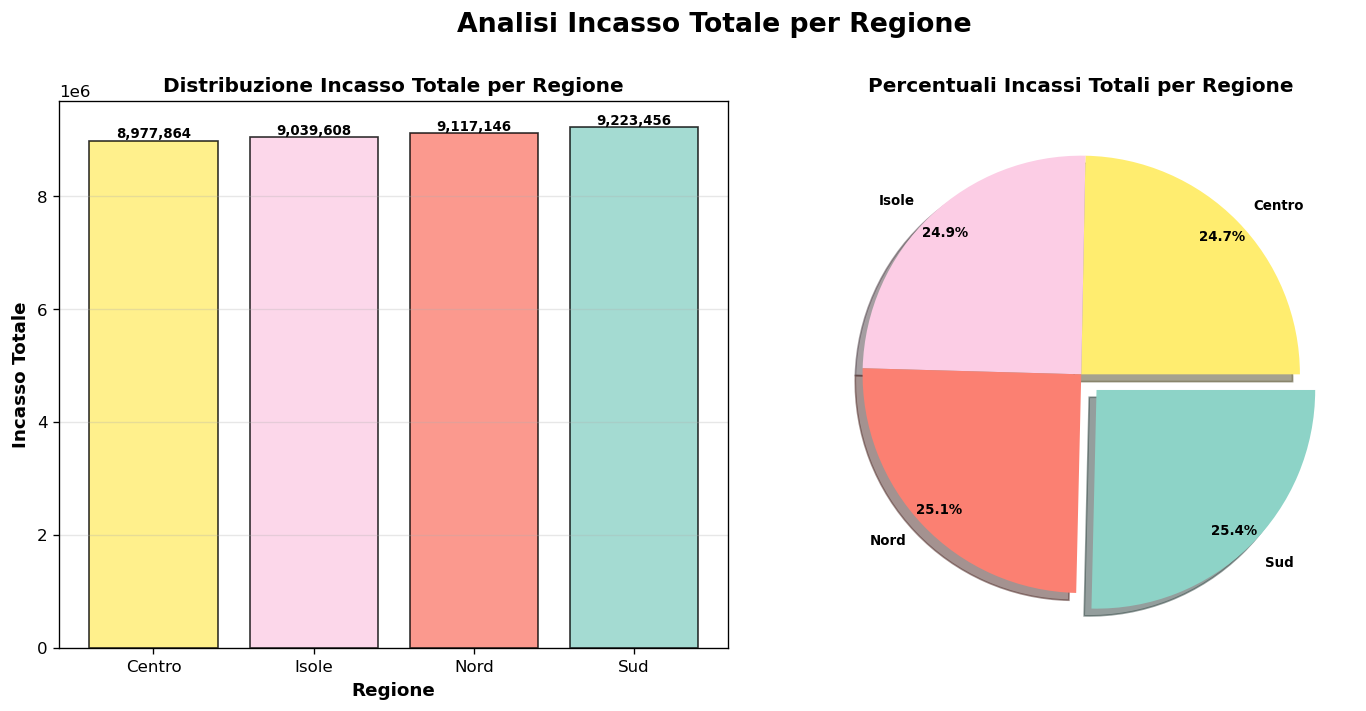

In [ ]:
## GRAFICO DISTRIBUZIONE INCASSO TOTALE PER REGIONE

fig, axes = plt.subplots(1, 2, figsize=(12,6), dpi=120)
fig.suptitle(f'Analisi Incasso Totale per Regione', fontsize=16, fontweight='bold')

# Mappa colori per grafico a barre e grafico a torta
colors = plt.cm.Set3_r(np.linspace(0, 1, len(analisi_regioni)))

# >>> Subplot 1 - Grafico a barre <<<

# Aggiungo barre
bars = axes[0].bar(analisi_regioni.index, analisi_regioni['Incasso_Totale'],
    color=colors, edgecolor='black', alpha=0.8)

# Aggiungo valore numerico sopra ogni barra
bar_value(axes[0], bars)

# Styling
axes[0].set_xlabel('Regione', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Incasso Totale', fontsize=11, fontweight='bold')
axes[0].set_title(f"Distribuzione Incasso Totale per Regione", fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# >>> Subplot 2 - Grafico a torta <<<

# Lista per evidenziare la regione più performante nel grafico a torta
explode = [
    0.1 
    if idx==analisi_regioni['Incasso_Totale'].idxmax() 
    else 0 
    for idx in analisi_regioni.index
]

# Aggiungo grafico a torta
axes[1].pie(
    analisi_regioni['Incasso_Totale'], 
    labels=analisi_regioni.index, 
    autopct='%1.1f%%',
    colors=colors,
    shadow=True,
    explode = explode,
    textprops={'fontsize': 8, 'fontweight': 'bold'},
    pctdistance=0.9
)
axes[1].set_title(f"Percentuali Incassi Totali per Regione", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()